In [50]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from segment_anything import sam_model_registry, SamPredictor
from segment_anything import SamAutomaticMaskGenerator

In [51]:
sam_checkpoint = "sam_vit_b.pth"
model_type = "vit_b"
device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [52]:
image = cv2.imread("image.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [ ]:
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=32,          # improves detection for drawings
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    min_mask_region_area=500     # removes tiny fragments
)

masks = mask_generator.generate(image)

print(f"Found {len(masks)} masks")


In [46]:
image_area = image.shape[0] * image.shape[1]

valid_masks = []

for i, m in enumerate(masks):

    area_ratio = m["area"] / image_area
    print(f"Mask {i}: area ratio = {area_ratio:.3f}")

    # Ignore background (too large)
    if area_ratio > 0.8:
        continue

    # Ignore tiny noise
    if area_ratio < 0.001:
        continue

    valid_masks.append(m["segmentation"])

if len(valid_masks) == 0:
    raise ValueError("No valid masks found.")

Mask 0: area ratio = 0.009
Mask 1: area ratio = 0.012
Mask 2: area ratio = 0.099
Mask 3: area ratio = 0.009
Mask 4: area ratio = 0.004
Mask 5: area ratio = 0.990
Mask 6: area ratio = 0.002
Mask 7: area ratio = 0.006
Mask 8: area ratio = 0.006
Mask 9: area ratio = 0.000
Mask 10: area ratio = 0.122
Mask 11: area ratio = 0.000
Mask 12: area ratio = 0.004
Mask 13: area ratio = 0.008


In [47]:
combined_mask = np.zeros_like(valid_masks[0], dtype=bool)

for m in valid_masks:
    combined_mask = combined_mask | m

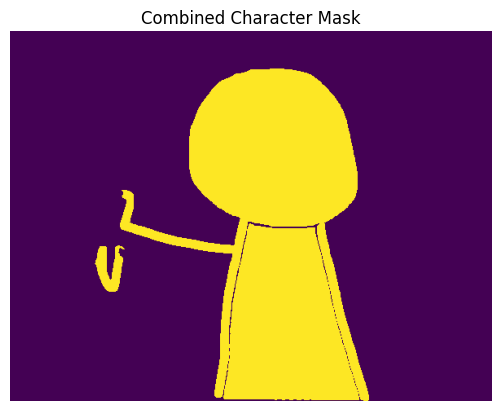

In [48]:
plt.imshow(combined_mask)
plt.title("Combined Character Mask")
plt.axis("off")
plt.show()

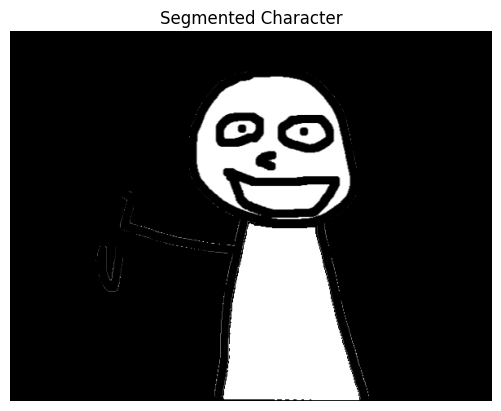

In [49]:
masked = image.copy()
masked[~combined_mask] = 0

plt.imshow(masked)
plt.title("Segmented Character")
plt.axis("off")
plt.show()

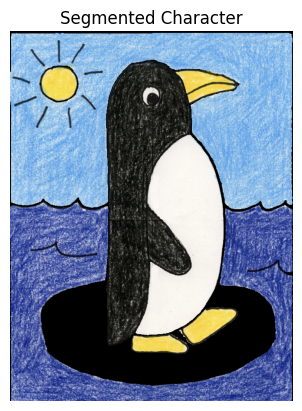

In [43]:
masked = image.copy()
masked[~combined_mask] = 0

plt.imshow(masked)
plt.title("Segmented Character")
plt.axis("off")
plt.show()